In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tools
from particles_cdssm.tools import build_cdssm, struct_arrs_to_arr
from particles_cdssm.cdssm_lib import CDSSM_LIB

# 

To do:

- Run the algorithms to obtain a benchmark, so that you can work with the MSE instead of the variance. 
- Using the ground truth results, create an extra MSE plot that will go into the main text.
- Optional: create an effective sample size plot of your developed guided proposal to include in the appendix of the paper. 

# Figure 8: Plot of the Logistic CD-SSM

In [2]:
def logistic_cdssm(lamperti=True):
    """
    Plots the Logistic CD-SSM and its Lamperti transform.
    """
    T = 10
    N_IMPUTED = 100
    THETA_3 = 0.7

    def lamperti_transform(x: np.ndarray, theta_3: float = THETA_3) -> np.ndarray:
        """Apply X = log(P) / theta_3."""
        x = np.asarray(x, dtype=np.float64)
        if np.any(x <= 0):
            raise ValueError("The Lamperti transform requires strictly positive values.")
        return np.log(x) / theta_3

    def inverse_lamperti_transform(x: np.ndarray, theta_3: float = THETA_3) -> np.ndarray:
        """Apply P = exp(theta_3 * X)."""
        x = np.asarray(x, dtype=np.float64)
        return np.exp(theta_3 * x)

    def plot_cdssm(
        ax: matplotlib.axes.Axes,
        x_t: np.ndarray,
        y_t: np.ndarray,
        x_arr: np.ndarray,
        y_arr: np.ndarray,
    ):
        ax.plot(
            x_t[:len(x_arr)],
            x_arr,
            color="#23a437",
            lw=2.0,
            label="Population - " + r"$P(s)$",
        )

        ax.scatter(
            y_t[:len(y_arr)],
            y_arr,
            color="#010101",
            marker="x",
            s=48,
            linewidths=1.5,
            zorder=10,
            label="Observations - " + r"$Y_t$",
        )

        ax.set_title("")
        ax.set_ylabel("Population - " + r"$P(s)$", fontsize=16)
        ax.tick_params(axis="y", labelsize=14)

        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=14)
        ax.set_xlim(0, T)

        return ax

    def plot_lamperti_transformed_sde(
        ax: matplotlib.axes.Axes,
        x_t: np.ndarray,
        x_arr: np.ndarray,
    ):
        lamperti_arr = lamperti_transform(x_arr)

        ax.plot(
            x_t[:len(lamperti_arr)],
            lamperti_arr,
            color="#e30808",
            lw=2.0,
            label="Lamperti transformed population - " + r"$X(s)$",
        )

        ax.set_title("")
        ax.set_xlabel("Time (s)", fontsize=16)
        ax.set_ylabel(r"$X(s) = \log(P(s)) / \theta_3$", fontsize=16)
        ax.set_xticks(np.arange(11).tolist())
        ax.tick_params(axis="both", labelsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="lower left", bbox_to_anchor=(0.00, 0.03), fontsize=14)
        ax.set_xlim(0, T)

        return ax

    def produce_figure(x_t: np.ndarray, y_t: np.ndarray, x_arr: np.ndarray, y_arr: np.ndarray):
        fig, axes = plt.subplots(2,1, figsize=(16, 6), sharex=True)
        
        axes[0] = plot_cdssm(axes[0], x_t, y_t, x_arr, y_arr)
        axes[1] = plot_lamperti_transformed_sde(axes[1], x_t, x_arr)
        
        fig.subplots_adjust(left=0.07, hspace=0.15, right=0.98)
        
        return fig, axes
            
        
    cdssm_name = 'LAMPERTI_LOGISTIC_NB_LOW' if lamperti else 'LOGISTIC_NB_LOW'
    cdssm = build_cdssm(CDSSM_LIB[cdssm_name])
    
    np.random.seed(55765)
    x, y = cdssm.simulate(T, num=N_IMPUTED)

    x_arr = struct_arrs_to_arr(x).ravel()
    y_arr = np.array(y).ravel()

    if lamperti:
        x_arr = inverse_lamperti_transform(x_arr, theta_3=THETA_3)
    
    x_t = np.linspace(start=1/len(x_arr), stop=T, num=len(x_arr))
    y_t = np.arange(1, T+1, dtype=np.int64)

    fig, axes = produce_figure(x_t, y_t, x_arr, y_arr)
    return fig, axes

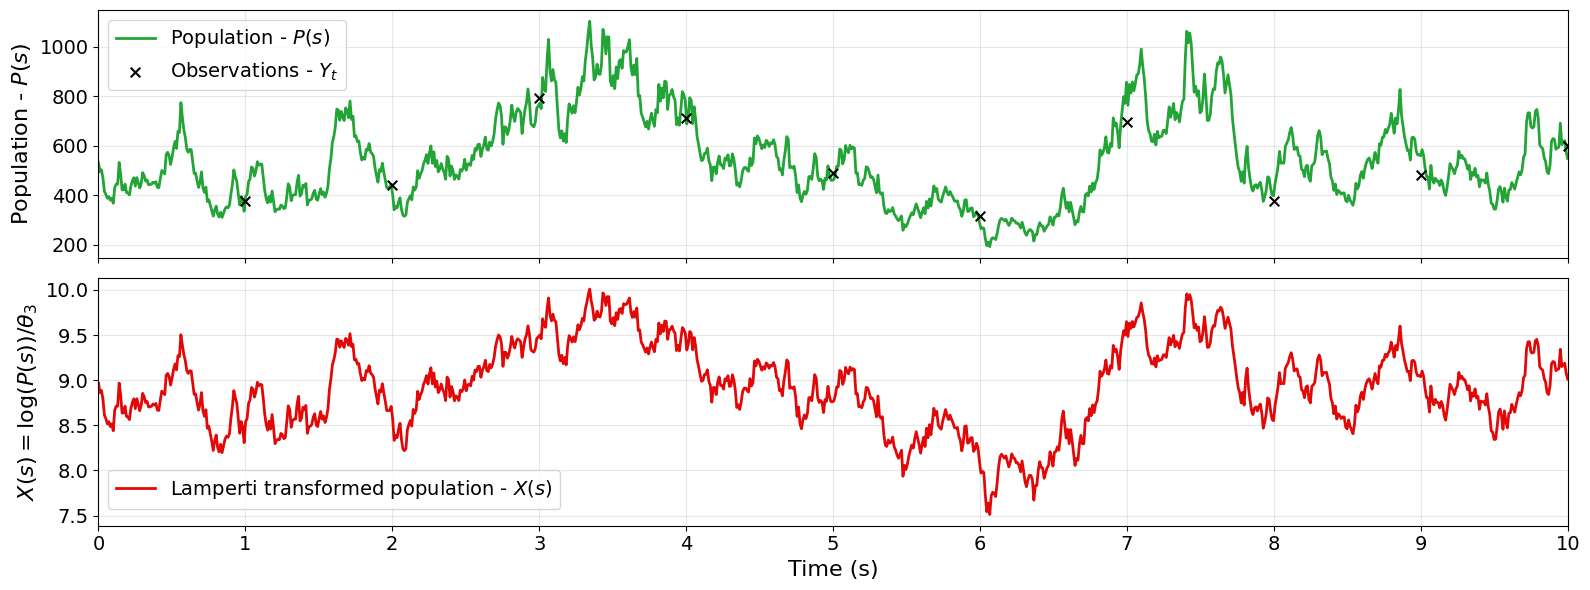

In [3]:
# fig, axes = plots.logistic_cdssm()
fig, axes = logistic_cdssm()

fig.tight_layout()
fig.savefig(
    "./figures/fig_8_logistic_cdssm.pdf",
    dpi=300,
    bbox_inches="tight"
)

# Figure 9: Variance of estimators plot

In [4]:
# Load and preprocess output data

boot_results = tools.load('logistic_int_config.json', remote=True)
guided_results = tools.load('logistic_int_g_config_1.json', remote=True)

boot_wide = boot_results['smc_wide']
guided_wide = guided_results['smc_wide']

boot_long = boot_results['smc_long']
guided_long = guided_results['smc_long']

boot_long['proposal'] = 'Bootstrap'
guided_long['proposal'] = 'Guided'

boot_wide['proposal'] = 'Bootstrap'
boot_wide['proposal'] = 'Guided'

all_wide = pd.concat([boot_wide, guided_wide], axis=0, ignore_index=True)
all_long = pd.concat([boot_long, guided_long], axis=0, ignore_index=True)

algo_map = {
    'naive':  r'GT: $\mathcal{O}(N)$, $N = 44{,}100$',
    'ON2':    r'FFBS: $\mathcal{O}(N^2)$, $N = 100$',
    'MCMC_1': r'FFBS-MCMC: $\mathcal{O}(N)$, $N = 11{,}000$',
}

palette = {
    r'GT: $\mathcal{O}(N)$, $N = 44{,}100$': "#d71212",
    r'FFBS: $\mathcal{O}(N^2)$, $N = 100$': "#1226d7",
    r'FFBS-MCMC: $\mathcal{O}(N)$, $N = 11{,}000$': "#0fabe3",
}

dfs = [boot_long, boot_wide, all_long, all_wide, guided_wide, guided_long]

for df in dfs:
    df['algorithm'] = df['algorithm'].map(algo_map) 

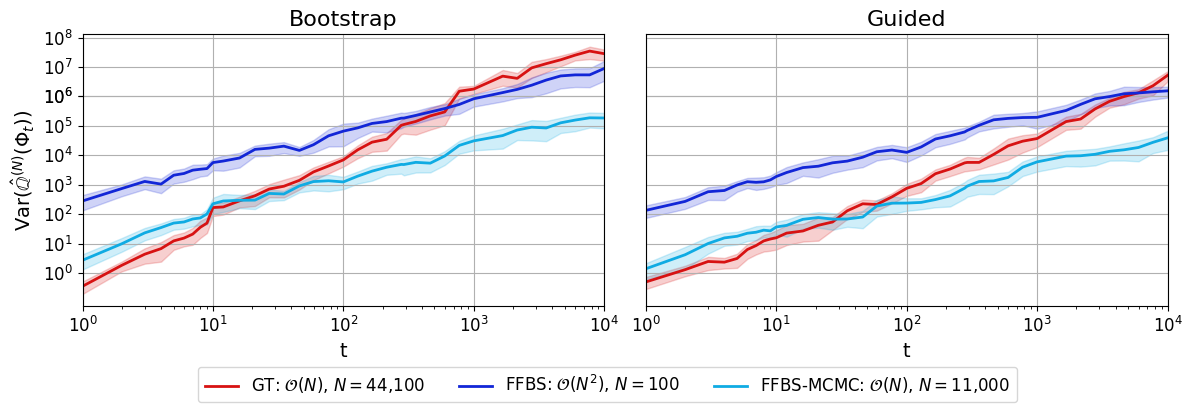

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

ax = axes[0]

sns.lineplot(
    ax=ax,
    data=boot_long,
    x='t',
    y='estimate',
    hue='algorithm',
    estimator=lambda x: np.var(x, ddof=1),
    palette=palette,
    errorbar=("ci", 95),
    n_boot=1000,
    linewidth=2.0
)

ax.set_xscale("log")
ax.set_title("Bootstrap", fontsize=16)
ax.set_xlim((10**0, 10 ** 4))
ax.grid()

ax = axes[1]

sns.lineplot(
    ax=ax,
    data=guided_long,
    x='t',
    y='estimate',
    hue='algorithm',
    estimator=lambda x: np.var(x, ddof=1),
    palette=palette,
    errorbar=("ci", 95),
    n_boot=1000,
    linewidth=2.0
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Guided", fontsize=16)
ax.set_xlim((10**0, 10 ** 4))

ax.tick_params(axis='y', which='both', left=False, right=False)
ax.set_yticks([10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6, 10**6, 10**7, 10**8])
ax.grid()

fig.subplots_adjust(wspace=0.08)
# fig.tight_layout()

axes[0].set_ylabel(r"$\mathrm{Var}(\hat{\mathbb{Q}}^{(N)}(\Phi_t))$", fontsize=14)
axes[0].set_xlabel("t", fontsize=14)
axes[1].set_xlabel("t", fontsize=14)
axes[0].tick_params(axis='both', labelsize=12)
axes[1].tick_params(axis='both', labelsize=12)

# Get legend information from one axis
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual axes
for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

# Add one shared legend below both panels
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=len(labels),
    fontsize=12
)

# Leave space at bottom for legend
fig.subplots_adjust(
    wspace=0.08,
    bottom=0.2
)

fig.savefig('./figures/fig_9_logistic_sde_results.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Bootstrap and Guided on the same plot

In [6]:
boot_long['proposal'] = 'Bootstrap'
guided_long['proposal'] = 'Guided'

all_long = pd.concat([boot_long, guided_long], axis=0, ignore_index=True)

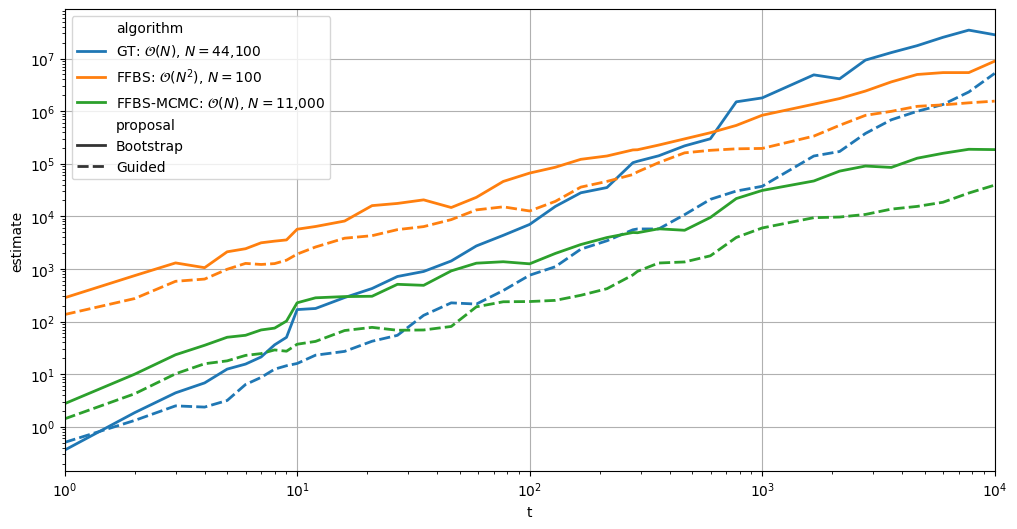

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.lineplot(
    ax=ax,
    data=all_long,
    x='t',
    y='estimate',
    hue='algorithm',
    style='proposal',
    estimator=lambda x: np.var(x, ddof=1),
    # errorbar=("ci", 95),
    errorbar=None,
    n_boot=1000,
    linewidth=2.0
)

ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim((1, 10 **4))
ax.grid()

# CPU Times of the Runs

Text(0.5, 1.0, 'guided')

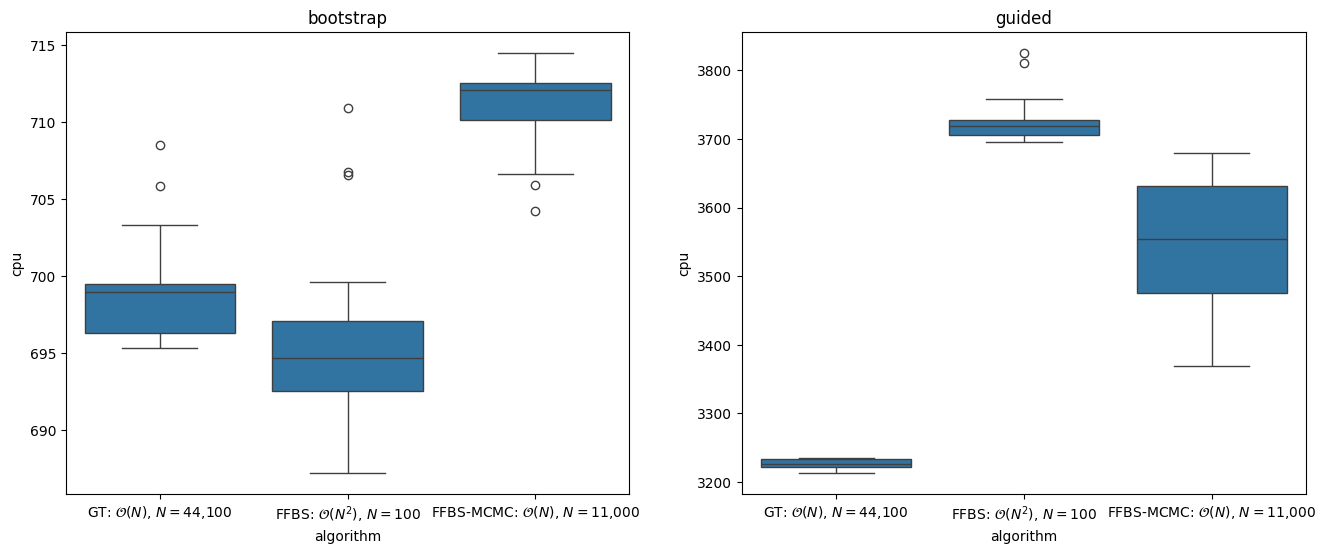

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.boxplot(ax=ax, x='algorithm', y='cpu', data=boot_wide)
ax.set_title("bootstrap")


ax = axes[1]
sns.boxplot(ax=ax, x='algorithm', y='cpu', data=guided_wide)
ax.set_title("guided")
